# Experiment Showcase — Multi-Axis Benchmarking

This notebook covers all three implemented benchmarking axes and shows
how to run experiments using the config-driven pipeline.

| Axis | Options |
|------|---------|
| **P0 — Axis 3: Feature Filtering** | MT · ribo · low-expr · HB · TCR/Ig VDJ · sex-chr · Gini-min |
| **P1 — Axis 4: Feature Selection** | `expr` · `zscore` · `tfidf` · `de` · `marker_panel` · `combined` |
| **P1 — Axis 2: Input Entity** | `single_cell` · `knn_smoothed` (k=5,20,100) · `pseudobulk` |

**Sections**
1. Setup — load data, compute global metrics + ADT (once)
2. Axis 3 — Feature Filtering: what each filter removes
3. Feature Selection: gene scoring strategies + parallel protein selection
4. Single-Cell Annotation: genes + proteins → prompt → LLM → result
5. Config system — load, inspect, override, dry-run
6. Run a single experiment
7. Run multiple experiments and compare results

In [2]:
%load_ext autoreload
%autoreload 2
import os, sys, warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
load_dotenv()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import sc_annotation as sca
from sc_annotation.config import ExperimentConfig, FilterConfig, SelectionConfig, InputConfig
from sc_annotation.filtering import build_gene_mask, summarise_mask
from sc_annotation.selection import (
    compute_scores, select_genes, select_by_marker_panel, MarkerPanel,
)
from sc_annotation.smoothing import build_knn_index, get_knn_indices, compute_pseudobulk
from sc_annotation.adt import build_adt_adata, normalize_adt, get_top_proteins
from sc_annotation.pipeline import run_experiment, build_backend, ensure_global_metrics
from sc_annotation.data import load_dataset, sample_cells
from sc_annotation.global_metrics import compute_global_metrics
from sc_annotation.backends import GeminiBackend

PBMC_PATH = 'scAnnotation_Datasets\Datasets\PBMC_CiteSeqRef\pbmc_citeseq_ref_2021.h5ad'
CONFIGS_DIR = 'configs'
print('Imports OK')

Imports OK


## 1. Load Dataset and Compute Global Metrics

Two parallel feature matrices are prepared once here and reused throughout:

| Modality | Normalization | Stored in |
|----------|--------------|-----------|
| RNA (33k genes) | lognorm — library-size to 10k + log1p | `adata.layers['lognorm']` |
| ADT (proteins) | CLR — center log-counts per cell around cell's own background | `adt_adata.layers['clr']` |

Population statistics (`mean_expr`, `std_expr`, `idf`) are derived from the RNA lognorm layer
and cached in `adata.var`. All downstream scoring and selection steps read from these precomputed quantities.

In [41]:
adata = load_dataset(PBMC_PATH)
print(adata)
print('\nLabel distribution (l1):')
print(adata.obs['celltype.l1'].value_counts())

AnnData object with n_obs × n_vars = 161764 × 33538
    obs: 'celltype.l1', 'celltype.l2', 'celltype.l3', 'donor', 'time', 'lane', 'Phase', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT'
    var: 'gene_symbol', 'feature_type'
    uns: 'ADT_names', 'dataset', 'source_geo'
    obsm: 'protein_counts'

Label distribution (l1):
celltype.l1
Mono       49010
CD4 T      41001
CD8 T      25469
NK         18664
B          13800
other T     6789
DC          3589
other       3442
Name: count, dtype: int64


In [4]:
%%time
compute_global_metrics(adata, n_top_hvg=2000, compute_gini=True, gini_scope='expressed', inplace=True)
print('var columns:', adata.var.columns.tolist())

INFO: Computing lognorm layer...
INFO: Computing population statistics...
INFO: Computing highly variable genes...
INFO: Computing Gini index...


Gini (expressed genes): 100%|██████████| 12016/12016 [00:06<00:00, 1743.58it/s]


var columns: ['gene_symbol', 'feature_type', 'mean_expr', 'std_expr', 'pct_cells', 'idf', 'is_low_expr', 'is_hvg', 'gini']
CPU times: total: 56.5 s
Wall time: 58.8 s


In [5]:
%%time
_ = build_knn_index(adata, k=10, use_rep='X_pca', inplace=True)

INFO: Computing PCA embedding with 50 components...
INFO: Building kNN index with k=10 on embedding 'X_pca'...
CPU times: total: 2min 7s
Wall time: 29.4 s


In [6]:
pb_reference_cell_idxs = compute_pseudobulk(adata, label_col='celltype.l2')

In [7]:
# ADT — parallel to RNA lognorm setup above
adt_adata = build_adt_adata(adata)
normalize_adt(adt_adata, method='clr', inplace=True)
print(f'ADT: {adt_adata.n_obs:,} cells × {adt_adata.n_vars} proteins, CLR-normalized')
print(f'Proteins: {list(adt_adata.var_names)}')

ADT: 161,764 cells × 228 proteins, CLR-normalized
Proteins: ['CD39', 'Rat-IgG1-1', 'CD107a', 'CD62P', 'TCR-2', 'CD30', 'CD31', 'CD34', 'CD35', 'CD36', 'CD223', 'TIGIT', 'TCR-V-9', 'CD226', 'CD178', 'CD319', 'CD171', 'Siglec-8', 'CD340', 'Rat-IgG2b', 'VEGFR-3', 'CD29', 'CD62E', 'CD4-2', 'CD4-1', 'CD22', 'CD3-1', 'CD20', 'CD27', 'CD45RB', 'CD25', 'CD24', 'CD146', 'Galectin-9', 'CD142', 'CD141', 'CD294', 'Rat-IgG1-2', 'CD45RA', 'CX3CR1', 'CD56-2', 'CD56-1', 'CD45RO', 'CD303', 'GP130', 'CD253', 'CD357', 'CD11b-1', 'CD354', 'CD11b-2', 'CLEC12A', 'CD38-2', 'CD38-1', 'Folate', 'Rag-IgG2c', 'CD209', 'CD152', 'CD154', 'CD155', 'Cadherin', 'CD201', 'CD204', 'CD205', 'CD206', 'CD207', 'CD1d', 'CD284', 'CD1c', 'Podoplanin', 'CD1a', 'CD366', 'IgD', 'IgM', 'CD66a/c/e', 'CD49d', 'LOX-1', 'TIM-4', 'CD98', 'CD370', 'CD49a', 'CD44-2', 'C5L2', 'CD44-1', 'CD158e1', 'CD124', 'CD127', 'CD126', 'CD279', 'CD278', 'CD123', 'CD122', 'CD96', 'CD274', 'CD95', 'CD271', 'CD270', 'CD90', 'CD272', 'CD16', 'CD14', 'CD

## 2. Feature Filtering

Each `FilterConfig` flag independently removes a class of uninformative genes.
We compare five progressively stricter filter presets.

In [8]:
filter_presets = {
    # 'none'              : FilterConfig(exclude_mt=False, exclude_ribo=False, exclude_low_expr=False),
    # 'mt_only'           : FilterConfig(exclude_mt=True,  exclude_ribo=False, exclude_low_expr=False),
    'mt+ribo'           : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=False),
    # 'conservative'      : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True),
    # 'conservative+hb'   : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True,
    #                                     exclude_hb=True),
    # 'conservative+tcrig': FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True,
    #                                     exclude_hb=True, exclude_tcr_ig=True),
    'strict'            : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True,
                                        exclude_hb=True, exclude_tcr_ig=True,
                                        exclude_sex_chr=True, gini_min=0.15),
}

rows = []
for name, fc in filter_presets.items():
    mask = build_gene_mask(adata, fc)
    s = summarise_mask(adata, mask)
    rows.append({'preset': name, 'included': s['included'], **s['excluded_by']})

filter_df = pd.DataFrame(rows).set_index('preset')
print('Genes included per filter preset:')
filter_df

Genes included per filter preset:


,included,is_mt,is_ribo,is_hb,is_tcr_vdj,is_sex_chr,is_low_expr,gini_housekeeping
preset,,,,,,,,
mt+ribo,33421,13,104,0,0,2,11,106
strict,11867,13,104,10,613,19,21522,149


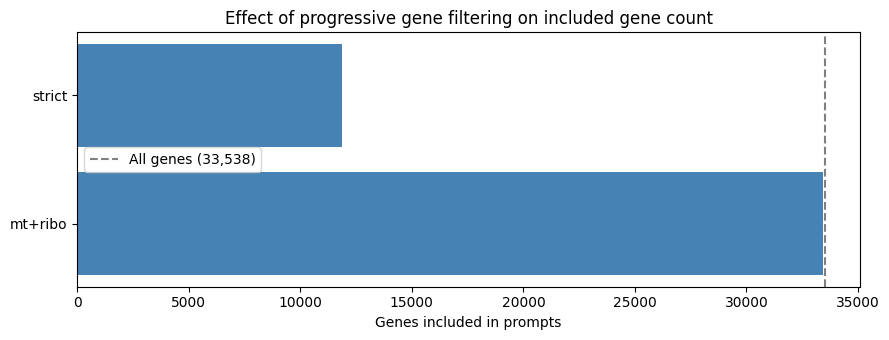

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(filter_df.index, filter_df['included'], color='steelblue')
ax.set_xlabel('Genes included in prompts')
ax.set_title('Effect of progressive gene filtering on included gene count')
ax.axvline(adata.n_vars, color='grey', linestyle='--', label=f'All genes ({adata.n_vars:,})')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Feature Selection: Genes and Proteins

Gene scoring strategies are compared side-by-side for the same input entity.
Protein (ADT) selection runs in parallel using the same `cell_indices` interface —
`get_top_proteins` averages raw counts across cells and re-applies CLR,
mirroring the pre-log mean aggregation used for RNA.

In [10]:
CELL_IDX  = np.random.choice(pb_reference_cell_idxs['HSPC'], size=1)[0]
gene_mask = build_gene_mask(adata, filter_presets['strict'])

true_l1 = adata.obs['celltype.l1'].iloc[CELL_IDX]
true_l2 = adata.obs['celltype.l2'].iloc[CELL_IDX]
true_l3 = adata.obs['celltype.l3'].iloc[CELL_IDX]
print(f'Cell {CELL_IDX} — true label: {true_l1} / {true_l2} / {true_l3}\n')

### Three different ways to define the input entity
cell_idx_single = [CELL_IDX]  # just the cell itself 

neighbor_index = build_knn_index(adata, 10, use_rep='X_pca', inplace=False)
cell_idx_10nn = get_knn_indices(CELL_IDX, neighbor_index, k=10)  # the 10 nearest neighbors of the cell

size = max(200, len(pb_reference_cell_idxs[true_l2]))
cell_idx_pb = np.random.choice(pb_reference_cell_idxs[true_l2], size=size, replace=False).tolist() + [CELL_IDX]  # random cells from the same L2 population + the cell itself

CELL_INPUT = cell_idx_single  # choose which input definition to use for the experiment

Cell 10761 — true label: other / HSPC / HSPC



In [11]:
# Venn-style overlap between strategies (top-100)
N_OVERLAP = 100
sets = {
    s: set(g for g, _ in select_genes(compute_scores(adata, CELL_INPUT, s, gene_mask), N_OVERLAP))
    for s in ['expr', 'zscore', 'tfidf']
}

print(f'Top-{N_OVERLAP} gene overlap between strategies:')
for a in ['expr', 'zscore', 'tfidf']:
    for b in ['expr', 'zscore', 'tfidf']:
        if b >= a:
            ov = len(sets[a] & sets[b])
            print(f'  {a:8s} ∩ {b:8s} = {ov}/{N_OVERLAP} ({ov/N_OVERLAP:.0%})')

Top-100 gene overlap between strategies:
  expr     ∩ expr     = 100/100 (100%)
  expr     ∩ zscore   = 6/100 (6%)
  expr     ∩ tfidf    = 16/100 (16%)
  zscore   ∩ zscore   = 100/100 (100%)
  tfidf    ∩ zscore   = 44/100 (44%)
  tfidf    ∩ tfidf    = 100/100 (100%)


In [12]:
# Parallel protein selection — same four strategies as gene scoring, same CELL_INPUT
# compute_scores(adt_adata, ..., layer='clr') is called internally by get_top_proteins,
# so expr / zscore / tfidf / de all work for proteins via the unified scoring pipeline.
N_PROT = 20
prot_sets = {
    s: set(p for p, _ in get_top_proteins(adt_adata, CELL_INPUT, n_top=N_PROT, strategy=s))
    for s in ['expr', 'zscore', 'de']
}

print(f'Top-{N_PROT} protein overlap between strategies (CELL_INPUT={len(CELL_INPUT)} cells):')
for a in ['expr', 'zscore', 'de']:
    for b in ['expr', 'zscore', 'de']:
        if b >= a:
            ov = len(prot_sets[a] & prot_sets[b])
            print(f'  {a:8s} ∩ {b:8s} = {ov}/{N_PROT} ({ov/N_PROT:.0%})')

print()
print('Top proteins by zscore:')
for name, score in get_top_proteins(adt_adata, CELL_INPUT, n_top=N_PROT, strategy='zscore'):
    print(f'  {name:<30s}  z={score:+.3f}')

Top-20 protein overlap between strategies (CELL_INPUT=1 cells):
  expr     ∩ expr     = 20/20 (100%)
  expr     ∩ zscore   = 4/20 (20%)
  zscore   ∩ zscore   = 20/20 (100%)
  de       ∩ expr     = 6/20 (30%)
  de       ∩ zscore   = 18/20 (90%)
  de       ∩ de       = 20/20 (100%)

Top proteins by zscore:
  CD34                            z=+4.942
  CD117                           z=+4.157
  CD71                            z=+3.782
  MERTK                           z=+2.433
  CD370                           z=+1.848
  Rat-IgG1-2                      z=+1.601
  CD112                           z=+1.523
  CD202b                          z=+1.462
  CD43                            z=+1.403
  CD69                            z=+1.401
  CCR10                           z=+1.374
  CD154                           z=+1.308
  CD133-2                         z=+1.250
  CD99                            z=+1.234
  CD206                           z=+1.217
  CD123                           z=+1.208
  CD46

## 4. Single-Cell Annotation: Genes → Prompt → LLM

A worked example of the full per-cell pipeline for one cell:
select top genes → build prompt → call the LLM → parse cell type and reasoning.

This mirrors exactly what `run_experiment` does inside its annotation loop.

In [13]:
from sc_annotation.prompts import SYSTEM_PROMPT, build_naive_prompt, build_enriched_prompt
from sc_annotation.metrics import extract_cell_type, extract_rationale

N_TOP = 100
TISSUE = 'PBMC'

print(f'Cell {CELL_IDX}  |  true label: {true_l1} / {true_l2}')
print(f'Using top-{N_TOP} genes (strict filter, {int(gene_mask.sum()):,} included) + top-20 proteins\n')

# --- Step 1a: score and select genes ---
scores_e     = compute_scores(adata, CELL_INPUT, 'expr',   gene_mask)
scores_z     = compute_scores(adata, CELL_INPUT, 'zscore', gene_mask)
scores_tfidf = compute_scores(adata, CELL_INPUT, 'tfidf',  gene_mask)

top_genes_e     = select_genes(scores_e, N_TOP)
top_genes_z     = select_genes(scores_z, N_TOP)
top_genes_tfidf = select_genes(scores_tfidf, N_TOP)

# --- Step 1b: score and select proteins (CLR layer, zscore strategy) ---
# compute_scores(adt_adata, ..., layer='clr') — same pipeline, different modality
proteins = get_top_proteins(adt_adata, CELL_INPUT, n_top=20, strategy='zscore')
print(f'Top proteins (zscore): {[p for p, _ in proteins]}')

Cell 10761  |  true label: other / HSPC
Using top-100 genes (strict filter, 11,867 included) + top-20 proteins

Top proteins (zscore): ['CD34', 'CD117', 'CD71', 'MERTK', 'CD370', 'Rat-IgG1-2', 'CD112', 'CD202b', 'CD43', 'CD69', 'CCR10', 'CD154', 'CD133-2', 'CD99', 'CD206', 'CD123', 'CD46', 'Rat-IgG1-1', 'CD79a', 'CD325']


In [26]:
# --- Step 2: call the LLM — genes + proteins for each scoring strategy ---
backend = GeminiBackend(
    model='gemini-2.5-flash',
    temperature=1.0,
    api_key=os.environ['GOOGLE_API_KEY'])

print(f'Cell {CELL_IDX}  |  true label: {true_l1} / {true_l2} / {true_l3}')
for name, tg in {
        'expr': top_genes_e,
        'zscore': top_genes_z,
        'tfidf': top_genes_tfidf
    }.items():
    prompt = build_naive_prompt(tg, proteins=proteins, tissue=TISSUE)
    response = backend.complete(prompt, system_message=SYSTEM_PROMPT)

    cell_type  = extract_cell_type(response)
    rationale  = extract_rationale(response)
    print(f"=============={name}==================")
    print(f'Predicted  : {cell_type}')
    print(f'Rationale  : {rationale}')

Cell 10761  |  true label: other / HSPC / HSPC
==============expr==================
Predicted  : Hematopoietic Progenitor Cell
Rationale  : High expression of surface markers CD34, CD117 (c-Kit), and CD71 (Transferrin Receptor) is characteristic of hematopoietic stem and progenitor cells. The gene profile shows active metabolism, cell cycle regulation (CDK6), and progenitor transcription factors (SOX4), consistent with an actively proliferating, immature cell type.
==============zscore==================
Predicted  : Plasmacytoid Dendritic Cell Progenitor
Rationale  : This cell expresses key hematopoietic progenitor markers CD34 and CD117, along with FLT3 and CD71 indicating proliferation and early lineage commitment. Strong expression of FCER1A and CD123 further points to a committed plasmacytoid dendritic cell (pDC) lineage, identifying it as a pDC precursor.
==============tfidf==================
Predicted  : Hematopoietic Stem/Progenitor Cell
Rationale  : Strong co-expression of key 

In [25]:
# --- Step 3: combined prompt — all three gene lists + proteins ---
N_TOP = 100

print(f'Cell {CELL_IDX}  |  true label: {true_l1} / {true_l2} / {true_l3} ')

prompt_combined = build_enriched_prompt(
    genes_by_expr=select_genes(scores_e, N_TOP),
    genes_by_zscore=select_genes(scores_z, N_TOP),
    genes_by_tfidf=select_genes(scores_tfidf, N_TOP),
    proteins=proteins,
    tissue=TISSUE,
)

response_combined = backend.complete(prompt_combined, system_message=SYSTEM_PROMPT)

print('=== combined prompt (genes + proteins) ===')
print(f'  Predicted: {extract_cell_type(response_combined)}')
print(f'  Rationale: {extract_rationale(response_combined)}')

Cell 10761  |  true label: other / HSPC / HSPC 
=== combined prompt (genes + proteins) ===
  Predicted: Dendritic Cell Precursor
  Rationale: This cell expresses key hematopoietic stem/progenitor markers CD34 and CD117, along with proliferation markers like CD71 and CDK6. Critically, it exhibits high expression of FLT3, FCER1A, and CD123, which are characteristic of early dendritic cell progenitors and precursors found in PBMC.


## 5. Stage-2 Refinement: Confirm / Polish Stage-1 Annotations via LLM Gene Programs

Stage-1 gives a coarse annotation (e.g. "CD8 T cell").
Stage-2 uses the stage-1 output as a starting point — not a hard constraint — and
refines it to the specific subtype, or corrects it when the evidence disagrees.

```
Stage-1 label  ──►  LLM: "what are the subtypes of X,
                          and what cell types are often confused with X?"
                          ↓ JSON gene programs
                    Score cell vs. each program (mean z-score)
                          ↓ pathway scores
                    LLM: genes + proteins + pathway scores
                          → confirm or correct stage-1, name specific subtype
```

**Key design choices**
- Programs are queried **per stage-1 label** and cached, so novel cell types work
  without any hardcoding.
- The query asks for **confused neighbors** (e.g. NK alongside CD8 T), so pathway
  scoring can detect outright misclassifications.
- `thinking_budget=0` is set for the JSON query call: Gemini 2.5 Flash spends
  thousands of thinking tokens before writing a single visible token, which exhausts
  small `max_output_tokens` budgets. Disabling thinking is appropriate for factual
  gene-list lookup.

In [30]:
from sc_annotation.stage2 import (
    make_gemini_json_caller,
    query_subtype_programs,
    filter_programs_to_panel,
    score_gene_programs,
    build_stage2_prompt,
)

# JSON caller for program queries — thinking_budget=0 keeps the full output budget
# for the actual JSON payload (see section header for explanation).
json_caller = make_gemini_json_caller(
    model='gemini-2.5-flash',
    api_key=os.environ['GOOGLE_API_KEY'],
    max_output_tokens=25600,
    thinking_budget=0,
)

# Separate backend for stage-2 reasoning (lower temperature = more deterministic)
stage2_backend = GeminiBackend(
    model='gemini-2.5-flash',
    temperature=0.0,
    api_key=os.environ['GOOGLE_API_KEY'])

print(f"Stage-2 helpers loaded.")

Stage-2 helpers loaded.


In [36]:
# ── Demo: single cell from Section 4 (CD8 TCM) ──────────────────────────────
stage1_label_demo    = extract_cell_type(response_combined)
stage1_reasoning_demo = extract_rationale(response_combined)
print(f"Stage-1 label   : '{stage1_label_demo}'")
print(f"Stage-1 reasoning: {stage1_reasoning_demo[:120]}...")
print(f"True label      : {true_l1} / {true_l2}\n")

raw_programs_demo = query_subtype_programs(
    stage1_label_demo, json_caller, tissue=TISSUE,
    stage1_reasoning=stage1_reasoning_demo,
)
programs_demo = filter_programs_to_panel(raw_programs_demo, adata)

print(f"Programs returned ({len(raw_programs_demo)} subtypes/types):\n")
for subtype, info in raw_programs_demo.items():
    n_found = len(programs_demo[subtype])
    n_total = len(info['genes'])
    print(f"  {subtype:<27s} {n_found:2d}/{n_total} in panel   {info['description'][:55]}")


Stage-1 label   : 'Dendritic Cell Precursor'
Stage-1 reasoning: This cell expresses key hematopoietic stem/progenitor markers CD34 and CD117, along with proliferation markers like CD71...
True label      : other / HSPC

Programs returned (7 subtypes/types):

  Plasmacytoid Dendritic Cell (pDC) Precursor 40/44 in panel   These are early progenitors committed to the pDC lineag
  Conventional Dendritic Cell Type 1 (cDC1) Precursor 37/42 in panel   These progenitors are committed to the cDC1 lineage, ex
  Conventional Dendritic Cell Type 2 (cDC2) Precursor 37/42 in panel   These progenitors are committed to the cDC2 lineage, ma
  Monocyte-Dendritic Cell Progenitor (MDP) 35/41 in panel   These are multipotent progenitors capable of differenti
  Hematopoietic Stem and Progenitor Cell (HSPC) 40/45 in panel   These are multipotent cells capable of self-renewal and
  Classical Monocyte          43/47 in panel   These are mature circulating monocytes characterized by
  Non-classical Monocyte    

In [ ]:
# Scoring method — three options:
#   'mean_z'  : mean z-score of program genes (simple, no background correction)
#   'tirosh'  : mean_z(program) − mean_z(background), where background genes are
#               sampled from the same expression-level bins as the program genes.
#               Replicates Scanpy score_genes (Tirosh 2016); community standard for
#               cell-type annotation.
#   'ucell'   : normalised Mann-Whitney U on per-cell gene ranks → score ∈ [0, 1].
#               Rank-based, dropout-robust; best per 2024 benchmark (Massimo et al.).

SCORE_METHOD = 'tirosh'

pw_demo = score_gene_programs(adata, CELL_INPUT, programs_demo, gene_mask, method=SCORE_METHOD)

print(f"\nPathway scores  [{SCORE_METHOD}]:\n")
for subtype, score in sorted(pw_demo.items(), key=lambda x: -x[1] if np.isfinite(x[1]) else -999):
    if np.isfinite(score):
        bar = '█' * max(0, int((score + 0.5) * 6)) if SCORE_METHOD != 'ucell' \
              else '█' * int(score * 15)
        print(f"  {subtype:<27s}: {score:+.3f}  {bar}")
    else:
        print(f"  {subtype:<27s}: n/a  (< 3 scoreable genes)")

s2_prompt_demo = build_stage2_prompt(
    stage1_label_demo,
    pw_demo,
    stage1_reasoning=stage1_reasoning_demo,
    genes_by_expr=top_genes_e,
    genes_by_zscore=top_genes_z,
    genes_by_tfidf=top_genes_tfidf,
    proteins=proteins,
    tissue=TISSUE,
)
s2_resp_demo = stage2_backend.complete(s2_prompt_demo, system_message=SYSTEM_PROMPT)

print(f"\n{'─'*55}")
print(f"True      : {true_l2}")
print(f"Stage-1   : {stage1_label_demo}")
print(f"Stage-2   : {extract_cell_type(s2_resp_demo)}")
print(f"Rationale : {extract_rationale(s2_resp_demo)}")



Pathway scores  [tirosh]:

  Conventional Dendritic Cell Type 2 (cDC2) Precursor: +0.674  ███████
  Monocyte-Dendritic Cell Progenitor (MDP): +0.658  ██████
  Conventional Dendritic Cell Type 1 (cDC1) Precursor: +0.589  ██████
  Plasmacytoid Dendritic Cell (pDC) Precursor: +0.519  ██████
  Hematopoietic Stem and Progenitor Cell (HSPC): +0.286  ████
  Classical Monocyte         : +0.022  ███
  Non-classical Monocyte     : -0.029  ██

───────────────────────────────────────────────────────
True      : HSPC
Stage-1   : Dendritic Cell Precursor
Stage-2   : Conventional Dendritic Cell Type 2 (cDC2) Precursor
Rationale : This cell expresses key progenitor markers (CD34, CD117, CD71, CDK6) and the DC lineage marker FCER1A. The highest pathway score is for "Conventional Dendritic Cell Type 2 (cDC2) Precursor," strongly supported by the overall gene and protein expression profile, indicating commitment towards the cDC2 lineage.


## Quick Reference

### CLI
```bash
# Dry run (validate config, no API calls)
python run_experiment.py configs/pbmc_l1_zscore_gemini.yaml --dry-run

# Run with override
python run_experiment.py configs/pbmc_l1_knn_k20.yaml --n-per-class 10 --results-dir my_results

# All configs
for f in configs/pbmc_l1_*.yaml; do
    python run_experiment.py $f --n-per-class 5
done
```

### Available configs
| File | Axis 2 | Axis 4 | Notes |
|------|--------|--------|-------|
| `pbmc_l1_baseline.yaml`     | single_cell | expr     | Simplest baseline |
| `pbmc_l1_zscore_gemini.yaml`| single_cell | zscore   | Default recommended |
| `pbmc_l1_tfidf.yaml`        | single_cell | tfidf    | Cell-rarity weighted |
| `pbmc_l1_combined.yaml`     | single_cell | combined | Dual expr+zscore prompt |
| `pbmc_l1_knn_k20.yaml`      | knn_k=20   | zscore   | Smoothed input |
| `pbmc_l1_pseudobulk.yaml`   | pseudobulk  | zscore   | Upper bound |
| `pbmc_l1_marker_panel.yaml` | single_cell | marker_panel | Structured markers |

### Extending
- **New filter**: add field to `FilterConfig` → logic in `filtering.build_gene_mask`
- **New strategy**: add `select_by_*` to `selection.py` → wire in `pipeline._select_genes`
- **New backend**: subclass `LLMBackend` → register in `pipeline.build_backend`
- **New prompt style**: add function to `prompts.py` → wire in `pipeline._build_prompt`